# ADR Prediction Model Comparison: DrugADRFusionModel vs DeepADRModel

This notebook compares two drug-centric ADR prediction models:
- **Your Model**: `DrugADRFusionModel` (contextual encoder-based)
- **Baseline**: `DeepADRModel` (projection-based)

## Workflow Overview
1. **Data Loading & Preparation** - Load and preprocess embeddings
2. **Model Definitions** - Define both models
3. **Model Initialization** - Setup models and dataloaders
4. **Evaluation Functions** - Define metrics computation
5. **Training Functions** - Define training loops
6. **Model Comparison** - Train both models and compare results

In [140]:

# ============================================================================
# STEP 1: IMPORTS & CONFIGURATION
# ============================================================================

import pandas as pd
import warnings
warnings.filterwarnings("ignore")
from pprint import pprint
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tabulate import tabulate
import asyncio
import nest_asyncio
import matplotlib.pyplot as plt

nest_asyncio.apply()

config = {
    "dataset":{
        "dti":"../../Data/scope_onside_common_v3.parquet",
        "adr":"../../Data/final_rxnorm_meddra_v2.parquet"
    },
    "protein_emb_1":{
        "path":  "../../Data/3. Protein_enbeddings/ESM_embeddings_(t33_650m model).parquet",
        "id_col": "id", 
        "emb_col": "embedding"
    },
    "protein_emb_2":{
        "path": "../../Data/3. Protein_enbeddings/GVP-GNN_protein_embeddings.parquet",
        "id_col": "uniprot_id", 
        "emb_col": "embedding"
    },
    "drug_emb_1":{
        "path": "../../Data/2. Drug_embeddings/EGNN_drug_embeddings_v2.parquet", 
        "id_col": "drug_chembl_id", 
        "emb_col": "embedding"
    },
    "drug_emb_2":{
        "path": "../../Data/2. Drug_embeddings/smiles_embeddings_chemberta.parquet", 
        "id_col": "drug_chembl_id", 
        "emb_col": "embedding"
    }
}

print("✅ Imports and configuration loaded successfully")

✅ Imports and configuration loaded successfully


In [141]:
# Load DTI data
dti_df = pd.read_parquet(config["dataset"]["dti"])
print(f"📊 DTI Data loaded: {dti_df.shape[0]:,} rows")

# Rename columns for consistency
dti_df = dti_df.rename(columns={"drug_chembl_id": "drug_id", "target_uniprot_id": "protein_id"})

df = dti_df.copy()
df = df[["drug_id", "protein_id", "label", "rxcui"]]

# Load and merge protein embeddings
if config["protein_emb_1"]["path"]:
    protein_emb_1_df = pd.read_parquet(config["protein_emb_1"]["path"])
    protein_emb_1_df = protein_emb_1_df.rename(columns={config["protein_emb_1"]["id_col"]: "protein_id"})
    df = df.merge(protein_emb_1_df[["protein_id", config["protein_emb_1"]["emb_col"]]], on="protein_id", how="left")
    df = df.rename(columns={config["protein_emb_1"]["emb_col"]: "prot_emb_1"})

if config["protein_emb_2"]["path"]:
    protein_emb_2_df = pd.read_parquet(config["protein_emb_2"]["path"])
    protein_emb_2_df = protein_emb_2_df.rename(columns={config["protein_emb_2"]["id_col"]: "protein_id"})
    df = df.merge(protein_emb_2_df[["protein_id", config["protein_emb_2"]["emb_col"]]], on="protein_id", how="left")
    df = df.rename(columns={config["protein_emb_2"]["emb_col"]: "prot_emb_2"})

# Load and merge drug embeddings
if config["drug_emb_1"]["path"]:
    drug_emb_1_df = pd.read_parquet(config["drug_emb_1"]["path"])
    drug_emb_1_df = drug_emb_1_df.rename(columns={config["drug_emb_1"]["id_col"]: "drug_id"})
    df = df.merge(drug_emb_1_df[["drug_id", config["drug_emb_1"]["emb_col"]]], on="drug_id", how="left")
    df = df.rename(columns={config["drug_emb_1"]["emb_col"]: "drug_emb_1"})

if config["drug_emb_2"]["path"]:
    drug_emb_2_df = pd.read_parquet(config["drug_emb_2"]["path"])
    drug_emb_2_df = drug_emb_2_df.rename(columns={config["drug_emb_2"]["id_col"]: "drug_id"})
    df = df.merge(drug_emb_2_df[["drug_id", config["drug_emb_2"]["emb_col"]]], on="drug_id", how="left")
    df = df.rename(columns={config["drug_emb_2"]["emb_col"]: "drug_emb_2"})

print(f"✅ All embeddings merged: {df.shape}")

📊 DTI Data loaded: 34,741 rows
✅ All embeddings merged: (34741, 8)


In [142]:

class ADRData:
    def __init__(self, id_to_name_dict):
        """
        Initializes with a dictionary of {meddra_id: meddra_name}.
        """
        self.id_to_name = id_to_name_dict
        self.unique_ids = sorted(list(id_to_name_dict.keys()))
        
        self.id_to_idx = {adr_id: i for i, adr_id in enumerate(self.unique_ids)}
        self.idx_to_id = {i: adr_id for i, adr_id in enumerate(self.unique_ids)}
        
        self.vocab_size = len(self.unique_ids)

    def encode(self, adr_list):
        """
        Takes a list of ADR IDs and returns a binary vector (1s and 0s).
        Example: ['10028553', '10003041'] -> [0, 1, 0, 0, 1...]
        """
        vector = np.zeros(self.vocab_size, dtype=np.int8)
        
        for adr_id in adr_list:
            if adr_id in self.id_to_idx:
                idx = self.id_to_idx[adr_id]
                vector[idx] = 1
            else:
                print(f"Warning: ADR ID {adr_id} not in vocabulary.")
                
        return vector

    def decode(self, vector):
        """
        Takes a binary vector and returns a list of human-readable ADR names.
        """
        decoded_names = []
        
        active_indices = np.where(vector == 1)[0]
        
        for idx in active_indices:
            adr_id = self.idx_to_id[idx]
            name = self.id_to_name.get(adr_id, "Unknown ADR")
            decoded_names.append(name)
            
        return decoded_names

    def decode_indices(self, indices):
        """
        Takes a list or array of indices (e.g., [42, 105, 300]) 
        and returns the corresponding ADR names.
        """
        return [self.id_to_name.get(self.idx_to_id[idx], "Unknown ADR") for idx in indices]

    def decode_top_k(self, confidence_array, k=5):
        """
        Takes the raw probability array from the model, finds the top K 
        highest values, and returns names + their confidence scores.
        """
        # Get indices of the top k probabilities
        top_indices = np.argsort(confidence_array)[-k:][::-1]
        
        results = []
        for idx in top_indices:
            adr_id = self.idx_to_id[idx]
            name = self.id_to_name.get(adr_id, "Unknown ADR")
            conf = confidence_array[idx]
            results.append({"name": name, "confidence": round(float(conf), 4)})
            
        return results

    def decode_with_threshold(self, confidence_array, threshold=0.5):
        """
        Returns all ADRs that pass a specific confidence threshold.
        Useful for seeing everything the model is "sure" about.
        """
        active_indices = np.where(confidence_array >= threshold)[0]
        
        # Sort them by confidence (highest first)
        active_indices = active_indices[np.argsort(confidence_array[active_indices])[::-1]]
        
        return [self.id_to_name.get(self.idx_to_id[idx], "Unknown ADR") for idx in active_indices]


In [143]:
adrdf = pd.read_parquet(config['dataset']["adr"])
id_name_dict = dict(zip(adrdf['meddra_id'], adrdf['meddra_name']))
adr_manager = ADRData(id_name_dict)

In [144]:
drug_to_adr_list = adrdf.groupby('rxnorm_ingredient_id')['meddra_id'].apply(list).to_dict()

def get_encoded_adr(drug_id):
    # Get the list of ADRs for this drug, or an empty list if not found
    adrs = drug_to_adr_list.get(drug_id, [])
    return adr_manager.encode(adrs)

# 2. Map the drug_id (e.g., rxcui) to the encoded vector
# This will create a column where each cell is a numpy array
df['adr'] = df['rxcui'].map(get_encoded_adr)
print(f"Total rows with ADRs: {df['adr'].apply(lambda x: x.sum() > 0).sum()}")

Total rows with ADRs: 34741


In [145]:
from sklearn.model_selection import train_test_split

# 1. Get all unique protein IDs
unique_proteins = df['protein_id'].unique()

# 2. Split protein IDs (not rows) to ensure no leakage
# We'll reserve 10% of proteins for Test and 10% for Validation
train_prot_ids, temp_prot_ids = train_test_split(
    unique_proteins, 
    test_size=0.20, 
    random_state=42
)

val_prot_ids, test_prot_ids = train_test_split(
    temp_prot_ids, 
    test_size=0.50, 
    random_state=42
)

# 3. Create the dataframes based on these ID splits
train_df = df[df['protein_id'].isin(train_prot_ids)]
val_df = df[df['protein_id'].isin(val_prot_ids)]
test_df = df[df['protein_id'].isin(test_prot_ids)]

# --- Verification & Metrics ---
print(f"--- Final Dataset Sizes ---")
print(f"Train Set: {len(train_df)} rows ({len(train_prot_ids)} proteins)")
print(f"Val Set:   {len(val_df)} rows ({len(val_prot_ids)} proteins) - [Model Selection]")
print(f"Test Set:  {len(test_df)} rows ({len(test_prot_ids)} proteins) - [Cold-Protein Eval]")

# 4. Recalculate Positive Weight for Training
num_neg = (train_df['label'] == 0).sum()
num_pos = (train_df['label'] == 1).sum()

# Avoid division by zero just in case
pos_weight_value = num_neg / num_pos if num_pos > 0 else 1.0

print(f"\nNew Positive Weight: {pos_weight_value:.2f}")
print(f"Positive/Negative Ratio in Train: 1:{num_neg/num_pos:.2f}")

--- Final Dataset Sizes ---
Train Set: 28055 rows (1908 proteins)
Val Set:   3335 rows (238 proteins) - [Model Selection]
Test Set:  3351 rows (239 proteins) - [Cold-Protein Eval]

New Positive Weight: 1.75
Positive/Negative Ratio in Train: 1:1.75


In [146]:

# ============================================================================
# STEP 2: MODEL ARCHITECTURES
# ============================================================================

class FusionModule(nn.Module):
    """Fuses two embeddings into a single representation."""
    def __init__(self, dim1, dim2, output_dim):
        super().__init__()
        self.fusion = nn.Sequential(
            nn.Linear(dim1 + dim2, output_dim),
            nn.LayerNorm(output_dim),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
    def forward(self, e1, e2):
        return self.fusion(torch.cat([e1, e2], dim=1))

class DrugADRFusionModel(nn.Module):
    """
    Your Model: Drug-to-ADR prediction using contextual encoder.
    - Fuses two drug embeddings
    - Passes through contextual encoder
    - Predicts both DTI (binding) and ADR (multi-label)
    """
    def __init__(self, drug_dims, adr_dim=4817, fused_dim=1028, latent_dim=512):
        super().__init__()
        
        # 1. Drug Fusion Layer
        self.drug_fusion = FusionModule(drug_dims[0], drug_dims[1], fused_dim)
        
        # 2. Contextual Encoder (drug-only, no protein)
        self.context_encoder = nn.Sequential(
            nn.Linear(fused_dim, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(0.1),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.1)
        )
        
        # 3. Latent Space Projection
        self.latent_projection = nn.Sequential(
            nn.Linear(512, latent_dim),
            nn.ReLU(),
            nn.BatchNorm1d(latent_dim)
        )
        
        # 4. ADR Prediction Head (deep network)
        self.adr_head = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.2),
            nn.Linear(256, adr_dim)
        )
    
    def forward(self, d1, d2):
        """Forward pass: drug embeddings → ADR predictions"""
        fused_drug = self.drug_fusion(d1, d2)
        context = self.context_encoder(fused_drug)
        drug_latent = self.latent_projection(context)
        adr_logits = self.adr_head(drug_latent)
        return adr_logits, drug_latent

print("✅ Model architectures defined")

✅ Model architectures defined


In [147]:

# ============================================================================
# STEP 4: EVALUATION FUNCTIONS
# ============================================================================

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    precision_recall_curve, auc, precision_score, recall_score, average_precision_score
)

def evaluate_multitask(model, dataloader, device):
    """Evaluation for DrugADRFusionModel (your model) - ADR only."""
    model.eval()
    
    adr_true, adr_probs = [], []

    with torch.no_grad():
        for d1, d2, p1, p2, labels, adr_targets in dataloader:
            d1 = d1.to(device, non_blocking=True)
            d2 = d2.to(device, non_blocking=True)
            
            adr_logits, _ = model(d1, d2)
            adr_p = torch.sigmoid(adr_logits).cpu().numpy()
            
            adr_true.extend(adr_targets.numpy())
            adr_probs.extend(adr_p)

    # ADR METRICS
    adr_true = np.array(adr_true)
    adr_probs = np.array(adr_probs)
    adr_preds = (adr_probs > 0.5).astype(int)
    
    adr_results = {
        "ADR_Micro_AUROC": roc_auc_score(adr_true, adr_probs, average='micro'),
        "ADR_Macro_AUROC": roc_auc_score(adr_true, adr_probs, average='macro'),
        "ADR_Weighted_AUROC": roc_auc_score(adr_true, adr_probs, average='weighted'),
        "ADR_Weighted_AUPRC": average_precision_score(adr_true, adr_probs, average='weighted'),
        "ADR_Micro_AUPRC": average_precision_score(adr_true, adr_probs, average='micro'),
        "ADR_Macro_AUPRC": average_precision_score(adr_true, adr_probs, average='macro'),
        "ADR_F1": f1_score(adr_true, adr_preds, average="weighted")
    }

    return adr_results

print("✅ Evaluation function defined")

✅ Evaluation function defined


In [148]:
class DTIVAE_Dataset(Dataset):
    """
    Optimized: converts dataframe columns to contiguous torch tensors ONCE in __init__.
    Avoids per-sample torch.tensor(...) calls (major CPU bottleneck).
    Uses chunked processing with progress bar for faster initialization.
    """
    def __init__(self, dataframe, verbose=True):
        df = dataframe.reset_index(drop=True)
        n_samples = len(df)
        
        if verbose:
            print(f"📦 Initializing dataset with {n_samples:,} samples...")

        def _stack_float(col_name):
            # Converts an object column (lists/np arrays) into a 2D float32 numpy array
            # Uses chunked processing for better memory efficiency
            arrs = df[col_name].to_numpy()
            result = np.empty((len(arrs), len(np.asarray(arrs[0], dtype=np.float32))), dtype=np.float32)
            
            # Process in chunks of 10K for progress feedback
            chunk_size = 10000
            for i in range(0, len(arrs), chunk_size):
                chunk_end = min(i + chunk_size, len(arrs))
                for j in range(i, chunk_end):
                    result[j] = np.asarray(arrs[j], dtype=np.float32)
                if verbose and i > 0:
                    print(f"  ✓ Processed {min(chunk_end, len(arrs)):,}/{len(arrs):,} rows...", end='\r')
            
            if verbose:
                print(f"  ✓ Stacked '{col_name}' ({len(arrs):,} rows)")
            return result

        def _stack_adr(col_name="adr"):
            arrs = df[col_name].to_numpy()
            result = np.empty((len(arrs), len(np.asarray(arrs[0], dtype=np.float32))), dtype=np.float32)
            
            chunk_size = 10000
            for i in range(0, len(arrs), chunk_size):
                chunk_end = min(i + chunk_size, len(arrs))
                for j in range(i, chunk_end):
                    result[j] = np.asarray(arrs[j], dtype=np.float32)
                if verbose and i > 0:
                    print(f"  ✓ Processed {min(chunk_end, len(arrs)):,}/{len(arrs):,} rows...", end='\r')
            
            if verbose:
                print(f"  ✓ Stacked '{col_name}' ({len(arrs):,} rows)")
            return result

        # Inputs
        if verbose:
            print("  Loading drug embeddings...")
        self.d1 = torch.from_numpy(_stack_float("drug_emb_1"))
        self.d2 = torch.from_numpy(_stack_float("drug_emb_2"))
        
        if verbose:
            print("  Loading protein embeddings...")
        self.p1 = torch.from_numpy(_stack_float("prot_emb_1"))
        self.p2 = torch.from_numpy(_stack_float("prot_emb_2"))

        # Targets
        if verbose:
            print("  Loading labels...")
        self.labels = torch.from_numpy(df["label"].to_numpy(dtype=np.float32))
        self.adr = torch.from_numpy(_stack_adr("adr"))
        
        if verbose:
            print(f"✅ Dataset ready! {n_samples:,} samples loaded\n")

    def __len__(self):
        return self.labels.shape[0]

    def __getitem__(self, idx):
        # No new tensor creation here — just indexing contiguous tensors
        return (
            self.d1[idx],
            self.d2[idx],
            self.p1[idx],
            self.p2[idx],
            self.labels[idx],
            self.adr[idx],
        )


In [149]:
import os
import torch
from torch.utils.data import DataLoader

# Detect Jupyter / IPython
def _in_notebook():
    try:
        from IPython import get_ipython
        return get_ipython() is not None and "IPKernelApp" in get_ipython().config
    except Exception:
        return False

pin = torch.cuda.is_available()

# Windows + Jupyter: multi-worker DataLoader frequently crashes due to spawn/pickling issues
if os.name == "nt" and _in_notebook():
    num_workers = 0
    persistent = False
    prefetch = None
else:
    cpu = os.cpu_count() or 4
    num_workers = min(8, max(2, cpu - 2))
    persistent = (num_workers > 0)
    prefetch = 4

train_loader = DataLoader(
    DTIVAE_Dataset(train_df),
    batch_size=64,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin,
    persistent_workers=persistent,
    prefetch_factor=prefetch
)

val_loader = DataLoader(
    DTIVAE_Dataset(val_df),
    batch_size=64,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin,
    persistent_workers=persistent,
    prefetch_factor=prefetch
)

test_loader = DataLoader(
    DTIVAE_Dataset(test_df),
    batch_size=64,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin,
    persistent_workers=persistent,
    prefetch_factor=prefetch
)

print(f"DataLoader: num_workers={num_workers}, pin_memory={pin}, persistent_workers={persistent}, prefetch_factor={prefetch}")


📦 Initializing dataset with 28,055 samples...
  Loading drug embeddings...
  ✓ Stacked 'drug_emb_1' (28,055 rows)
  ✓ Stacked 'drug_emb_2' (28,055 rows)
  Loading protein embeddings...
  ✓ Stacked 'prot_emb_1' (28,055 rows)
  ✓ Stacked 'prot_emb_2' (28,055 rows)
  Loading labels...
  ✓ Stacked 'adr' (28,055 rows)s...
✅ Dataset ready! 28,055 samples loaded

📦 Initializing dataset with 3,335 samples...
  Loading drug embeddings...
  ✓ Stacked 'drug_emb_1' (3,335 rows)
  ✓ Stacked 'drug_emb_2' (3,335 rows)
  Loading protein embeddings...
  ✓ Stacked 'prot_emb_1' (3,335 rows)
  ✓ Stacked 'prot_emb_2' (3,335 rows)
  Loading labels...
  ✓ Stacked 'adr' (3,335 rows)
✅ Dataset ready! 3,335 samples loaded

📦 Initializing dataset with 3,351 samples...
  Loading drug embeddings...
  ✓ Stacked 'drug_emb_1' (3,351 rows)
  ✓ Stacked 'drug_emb_2' (3,351 rows)
  Loading protein embeddings...
  ✓ Stacked 'prot_emb_1' (3,351 rows)
  ✓ Stacked 'prot_emb_2' (3,351 rows)
  Loading labels...
  ✓ Stacked 'ad

In [150]:

# ============================================================================
# STEP 5: TRAINING FUNCTIONS
# ============================================================================

def train_model(model, train_loader, test_loader, val_loader, pos_weight, epochs=50, lr=1e-4, device='cuda'):
    """
    Training loop for DrugADRFusionModel (your model) - ADR only.
    Prints metrics every epoch.
    """
    model.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.2, min_lr=1e-6)
    
    best_val_score = -1
    
    print(f"🚀 Training DrugADRFusionModel ({sum(p.numel() for p in model.parameters()):,} params)...")
    print(f"   Task: ADR Prediction (Multi-label)\n")
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        
        for d1, d2, p1, p2, labels, adr_targets in train_loader:
            d1, d2 = d1.to(device, non_blocking=True), d2.to(device, non_blocking=True)
            adr_targets = adr_targets.to(device, non_blocking=True)

            optimizer.zero_grad()
            
            # Forward pass
            adr_logits, _ = model(d1, d2)
            
            # ADR loss
            loss_adr = F.binary_cross_entropy_with_logits(adr_logits, adr_targets)
            
            loss_adr.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_losses.append(loss_adr.detach().cpu())
            
        # Evaluate on validation set
        val_metrics = evaluate_multitask(model, val_loader, device)
        
        score = val_metrics['ADR_Weighted_AUPRC']
        is_best = score > best_val_score
        
        if is_best:
            best_val_score = score
            torch.save(model.state_dict(), 'best_drug_adr_model.pth')
            best_marker = " ⭐ BEST"
        else:
            best_marker = ""
            
        scheduler.step(score)
        
        # Print every epoch
        avg_loss = np.mean(train_losses)
        print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {avg_loss:.4f} | Val - Micro AUROC: {val_metrics['ADR_Micro_AUROC']:.4f} | "
              f"Macro AUROC: {val_metrics['ADR_Macro_AUROC']:.4f} | Weighted AUROC: {val_metrics['ADR_Weighted_AUROC']:.4f} | "
              f"Micro AUPRC: {val_metrics['ADR_Micro_AUPRC']:.4f} | Macro AUPRC: {val_metrics['ADR_Macro_AUPRC']:.4f} | "
              f"Weighted AUPRC: {val_metrics['ADR_Weighted_AUPRC']:.4f} | F1: {val_metrics['ADR_F1']:.4f}{best_marker}")

    return model

print("✅ Training function defined")

✅ Training function defined


In [151]:

# ============================================================================
# STEP 3: MODEL INITIALIZATION & SETUP
# ============================================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 Using device: {device}")

sample_row = train_df.iloc[0]

# Detect dimensions
d1_dim = len(sample_row['drug_emb_1'])
d2_dim = len(sample_row['drug_emb_2'])
p1_dim = len(sample_row['prot_emb_1'])
p2_dim = len(sample_row['prot_emb_2'])
num_adrs = adr_manager.vocab_size

print(f"\n📐 Detected Dimensions:")
print(f"   Drug Embeddings: {d1_dim}D + {d2_dim}D")
print(f"   Protein Embeddings: {p1_dim}D + {p2_dim}D (NOT USED)")
print(f"   ADR Labels: {num_adrs}")

# Initialize both models
model = DrugADRFusionModel(
    drug_dims=[d1_dim, d2_dim],
    adr_dim=num_adrs,
    fused_dim=1028,
    latent_dim=512
).to(device)

deepadr_model = DeepADRModel(
    drug_dims=[d1_dim, d2_dim],
    adr_dim=num_adrs,
    fused_dim=1028,
    latent_dim=512
).to(device)

model_params = sum(p.numel() for p in model.parameters())
deepadr_params = sum(p.numel() for p in deepadr_model.parameters())

print(f"\n✅ Models initialized:")
print(f"   DrugADRFusionModel:  {model_params:,} parameters")
print(f"   DeepADRModel:        {deepadr_params:,} parameters")
print(f"   Ratio: {model_params/deepadr_params:.2f}x")


🔧 Using device: cuda

📐 Detected Dimensions:
   Drug Embeddings: 256D + 384D
   Protein Embeddings: 1280D + 1024D (NOT USED)
   ADR Labels: 4817

✅ Models initialized:
   DrugADRFusionModel:  4,139,741 parameters
   DeepADRModel:        2,238,941 parameters
   Ratio: 1.85x


In [152]:

# ============================================================================
# DEEPADR MODEL ARCHITECTURE
# A focused, drug-centric ADR prediction model
# ============================================================================

class DeepADRHead(nn.Module):
    """
    DeepADR-inspired ADR prediction head.
    - Focuses on drug embeddings alone (simpler baseline)
    - Uses deep non-linear transformations
    - Each ADR gets an independent prediction
    
    Args:
        drug_fused_dim: Dimension of fused drug representation
        num_adrs: Number of ADRs (e.g., 4817)
        hidden_dims: List of hidden layer dimensions
        dropout_rate: Dropout probability
    """
    def __init__(self, drug_fused_dim, num_adrs=4817, hidden_dims=[1024, 512, 256], dropout_rate=0.2):
        super(DeepADRHead, self).__init__()
        
        self.drug_fused_dim = drug_fused_dim
        self.num_adrs = num_adrs
        
        # Build hidden layers
        layers = []
        input_dim = drug_fused_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(dropout_rate)
            ])
            input_dim = hidden_dim
        
        # Output layer for ADR predictions
        layers.append(nn.Linear(input_dim, num_adrs))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, drug_fused):
        """
        Args:
            drug_fused: [B, drug_fused_dim]
        Returns:
            adr_logits: [B, num_adrs] (raw logits)
        """
        return self.network(drug_fused)


class DeepADRModel(nn.Module):
    """
    Complete DeepADR model: focuses on drug-to-ADR prediction.
    - Uses only drug embeddings (not protein info)
    - Parallel DTI head for comparison with your VAE model
    - Simpler baseline to benchmark against the VAE
    """
    def __init__(self, drug_dims, adr_dim=4817, fused_dim=768, latent_dim=256):
        super(DeepADRModel, self).__init__()
        
        # 1. Drug Fusion (same as your VAE)
        self.drug_fusion = FusionModule(drug_dims[0], drug_dims[1], fused_dim)
        
        # 2. Simple projection to latent space
        self.drug_projection = nn.Sequential(
            nn.Linear(fused_dim, latent_dim),
            nn.ReLU(),
            nn.BatchNorm1d(latent_dim),
            nn.Dropout(0.1)
        )
        
        # 3. Deep ADR Head (drug-centric only)
        self.adr_head = DeepADRHead(
            drug_fused_dim=latent_dim,
            num_adrs=adr_dim,
            hidden_dims=[512, 256, 128],
            dropout_rate=0.2
        )
    
    def forward(self, d1, d2):
        """
        Args:
            d1, d2: Drug embeddings [B, dim]
        Returns:
            adr_logits: [B, num_adrs] (ADR prediction)
        """
        # Fuse drug embeddings
        fused_drug = self.drug_fusion(d1, d2)
        
        # Project to latent space
        drug_latent = self.drug_projection(fused_drug)
        
        # Predictions
        adr_logits = self.adr_head(drug_latent)
        
        return adr_logits


In [153]:

# ============================================================================
# EVALUATION FOR DEEPADR
# ============================================================================

def evaluate_deepadr(model, dataloader, device):
    """Evaluation for DeepADRModel - ADR only."""
    model.eval()
    
    adr_true, adr_probs = [], []

    with torch.no_grad():
        for d1, d2, p1, p2, labels, adr_targets in dataloader:
            d1 = d1.to(device, non_blocking=True)
            d2 = d2.to(device, non_blocking=True)
            
            adr_logits = model(d1, d2)  # ADR only
            adr_p = torch.sigmoid(adr_logits).cpu().numpy()
            
            adr_true.extend(adr_targets.numpy())
            adr_probs.extend(adr_p)

    # ADR METRICS
    adr_true = np.array(adr_true)
    adr_probs = np.array(adr_probs)
    adr_preds = (adr_probs > 0.5).astype(int)
    
    adr_results = {
        "ADR_Micro_AUROC": roc_auc_score(adr_true, adr_probs, average='micro'),
        "ADR_Macro_AUROC": roc_auc_score(adr_true, adr_probs, average='macro'),
        "ADR_Weighted_AUROC": roc_auc_score(adr_true, adr_probs, average='weighted'),
        "ADR_Weighted_AUPRC": average_precision_score(adr_true, adr_probs, average='weighted'),
        "ADR_Micro_AUPRC": average_precision_score(adr_true, adr_probs, average='micro'),
        "ADR_Macro_AUPRC": average_precision_score(adr_true, adr_probs, average='macro'),
        "ADR_F1": f1_score(adr_true, adr_preds, average="weighted")
    }

    return adr_results

print("✅ DeepADR evaluation function defined")

✅ DeepADR evaluation function defined


In [154]:

# ============================================================================
# TRAINING FOR DEEPADR
# ============================================================================

def train_deepadr_model(model, train_loader, test_loader, val_loader, pos_weight, epochs=50, lr=1e-4, device='cuda'):
    """
    Training loop for DeepADRModel - ADR only.
    Prints metrics every epoch.
    """
    model.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.2, min_lr=1e-6)
    
    best_val_auprc = -1
    
    print(f"🚀 Training DeepADRModel ({sum(p.numel() for p in model.parameters()):,} params)...")
    print(f"   Task: ADR Prediction (Multi-label)\n")
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        
        for d1, d2, p1, p2, labels, adr_targets in train_loader:
            d1, d2 = d1.to(device, non_blocking=True), d2.to(device, non_blocking=True)
            adr_targets = adr_targets.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            
            # Forward pass (ADR only)
            adr_logits = model(d1, d2)
            
            # ADR loss
            loss_adr = F.binary_cross_entropy_with_logits(adr_logits, adr_targets)
            
            loss_adr.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_losses.append(loss_adr.detach().cpu())
        
        # Evaluate on validation set
        val_metrics = evaluate_deepadr(model, val_loader, device)
        
        score = val_metrics['ADR_Weighted_AUPRC']
        
        if score > best_val_auprc:
            best_val_auprc = score
            torch.save(model.state_dict(), 'best_deepadr_model.pth')
            best_marker = " ⭐ BEST"
        else:
            best_marker = ""
        
        scheduler.step(score)
        
        # Print every epoch
        avg_loss = np.mean(train_losses)
        print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {avg_loss:.4f} | Val - Micro AUROC: {val_metrics['ADR_Micro_AUROC']:.4f} | "
              f"Macro AUROC: {val_metrics['ADR_Macro_AUROC']:.4f} | Weighted AUROC: {val_metrics['ADR_Weighted_AUROC']:.4f} | "
              f"Micro AUPRC: {val_metrics['ADR_Micro_AUPRC']:.4f} | Macro AUPRC: {val_metrics['ADR_Macro_AUPRC']:.4f} | "
              f"Weighted AUPRC: {val_metrics['ADR_Weighted_AUPRC']:.4f} | F1: {val_metrics['ADR_F1']:.4f}{best_marker}")

    return model

print("✅ DeepADR training function defined")

✅ DeepADR training function defined


In [155]:

# ============================================================================
# STEP 6: MODEL COMPARISON FUNCTIONS
# ============================================================================

def compare_models_comprehensive(your_val_metrics, deepadr_val_metrics, your_test_metrics, deepadr_test_metrics):
    """Compare performance between DrugADRFusionModel and DeepADRModel on both validation and test sets."""
    
    adr_metrics = ['ADR_Micro_AUROC', 'ADR_Weighted_AUROC', 'ADR_Micro_AUPRC', 'ADR_Weighted_AUPRC', 'ADR_F1']
    
    # ─────────────────────────────────────────────────────────────────────────────
    # VALIDATION SET COMPARISON
    # ─────────────────────────────────────────────────────────────────────────────
    
    print(f"\n{'='*110}")
    print(f"📊 MODEL COMPARISON - VALIDATION SET")
    print(f"{'='*110}\n")
    
    comparison_data = []
    for metric in adr_metrics:
        your_val = your_val_metrics.get(metric, 0)
        deep_val = deepadr_val_metrics.get(metric, 0)
        diff = your_val - deep_val
        winner = "🔵 DrugADRFusion" if diff > 0 else "🟠 DeepADR" if diff < 0 else "🟡 TIED"
        comparison_data.append([metric, f"{your_val:.4f}", f"{deep_val:.4f}", f"{diff:+.4f}", winner])
    
    headers = ["Metric", "DrugADRFusion", "DeepADR", "Δ (Fusion-ADR)", "Winner"]
    print(tabulate(comparison_data, headers=headers, tablefmt="fancy_grid"))
    
def plot_comparison(your_val_metrics, deepadr_val_metrics, your_test_metrics, deepadr_test_metrics):
    """Visualize ADR performance comparison on both validation and test sets."""
    # ─────────────────────────────────────────────────────────────────────────────
    
    adr_metrics = ['ADR_Micro_AUROC', 'ADR_Weighted_AUROC', 'ADR_Micro_AUPRC', 'ADR_Weighted_AUPRC', 'ADR_F1']
    
    # Validation metrics
    your_val = [your_val_metrics[m] for m in adr_metrics]
    deepadr_val = [deepadr_val_metrics[m] for m in adr_metrics]
    
    # Test metrics
    your_test = [your_test_metrics[m] for m in adr_metrics]
    deepadr_test = [deepadr_test_metrics[m] for m in adr_metrics]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    x = np.arange(len(adr_metrics))
    width = 0.25
    
    # Validation set comparison
    axes[0].bar(x - width, your_val, width, label='DrugADRFusion', alpha=0.8, color='#1f77b4')
    axes[0].bar(x, deepadr_val, width, label='DeepADR', alpha=0.8, color='#ff7f0e')
    axes[0].set_ylabel('Score', fontsize=11, fontweight='bold')
    axes[0].set_title('Validation Set Performance', fontsize=12, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([m.replace('ADR_', '') for m in adr_metrics], rotation=45, ha='right')
    axes[0].legend(fontsize=10)
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].set_ylim([0, 1])
    
    # Test set comparison
    axes[1].bar(x - width, your_test, width, label='DrugADRFusion', alpha=0.8, color='#1f77b4')
    axes[1].bar(x, deepadr_test, width, label='DeepADR', alpha=0.8, color='#ff7f0e')
    axes[1].set_ylabel('Score', fontsize=11, fontweight='bold')
    axes[1].set_title('Test Set Performance', fontsize=12, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([m.replace('ADR_', '') for m in adr_metrics], rotation=45, ha='right')
    axes[1].legend(fontsize=10)
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].set_ylim([0, 1])
    
    fig.suptitle('ADR Prediction Performance Comparison\nValidation vs Test Sets', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.savefig('model_comparison_val_test.png', dpi=150, bbox_inches='tight')
    plt.show()

print("✅ Comparison functions defined")

✅ Comparison functions defined



🚀 STARTING TRAINING FOR BOTH MODELS

PHASE 1: Training DrugADRFusionModel (Contextual Encoder)
--------------------------------------------------------------------------------------------------------------
🚀 Training DrugADRFusionModel (4,139,741 params)...
   Task: ADR Prediction (Multi-label)

Epoch   1/40 | Loss: 0.2269 | Val - Micro AUROC: 0.9671 | Macro AUROC: nan | Weighted AUROC: 0.8138 | Micro AUPRC: 0.5605 | Macro AUPRC: 0.1449 | Weighted AUPRC: 0.5636 | F1: 0.3208 ⭐ BEST
Epoch   2/40 | Loss: 0.0725 | Val - Micro AUROC: 0.9735 | Macro AUROC: nan | Weighted AUROC: 0.8572 | Micro AUPRC: 0.6460 | Macro AUPRC: 0.2187 | Weighted AUPRC: 0.6657 | F1: 0.3874 ⭐ BEST
Epoch   3/40 | Loss: 0.0594 | Val - Micro AUROC: 0.9768 | Macro AUROC: nan | Weighted AUROC: 0.8886 | Micro AUPRC: 0.6997 | Macro AUPRC: 0.2149 | Weighted AUPRC: 0.7072 | F1: 0.5092 ⭐ BEST
Epoch   4/40 | Loss: 0.0546 | Val - Micro AUROC: 0.9735 | Macro AUROC: nan | Weighted AUROC: 0.8967 | Micro AUPRC: 0.6920 | Macro AUPRC

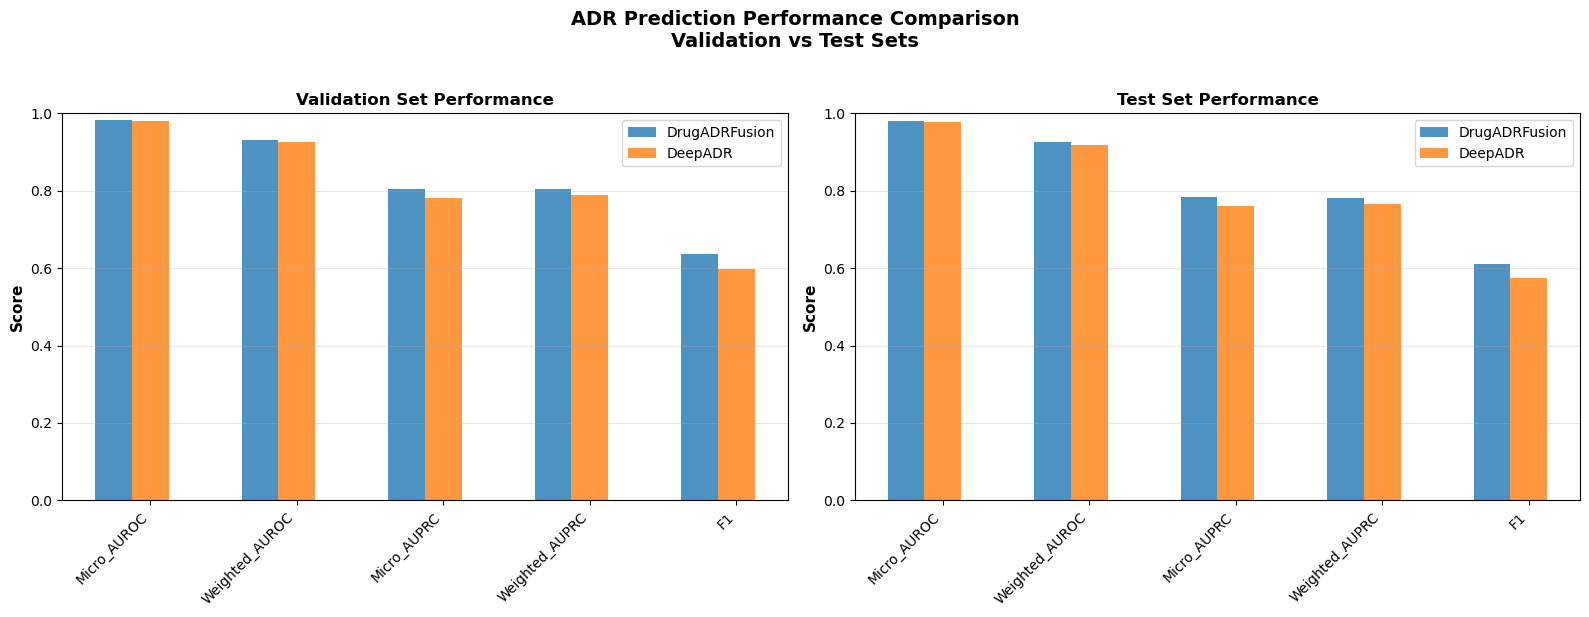


📊 FINAL PERFORMANCE SUMMARY

┌─ VALIDATION SET ─────────────────────────────────────────────────────────────────────────────┐
│
│ 🔵 DrugADRFusionModel Performance:
│    ADR_Weighted_AUROC: 0.9318
│    ADR_Weighted_AUPRC: 0.8045
│    ADR_F1: 0.6361
│
│ 🟠 DeepADRModel Performance:
│    ADR_Weighted_AUROC: 0.9256
│    ADR_Weighted_AUPRC: 0.7885
│    ADR_F1: 0.5988
│
│ 📈 Improvements:
│    ADR_Weighted_AUROC: +0.0062 (+0.67%) ✅
│    ADR_Weighted_AUPRC: +0.0161 (+2.04%) ✅
│    ADR_F1: +0.0374 (+6.24%) ✅
│
└──────────────────────────────────────────────────────────────────────────────────────────────┘

┌─ TEST SET ─────────────────────────────────────────────────────────────────────────────────┐
│
│ 🔵 DrugADRFusionModel Performance:
│    ADR_Weighted_AUROC: 0.9254
│    ADR_Weighted_AUPRC: 0.7812
│    ADR_F1: 0.6103
│
│ 🟠 DeepADRModel Performance:
│    ADR_Weighted_AUROC: 0.9192
│    ADR_Weighted_AUPRC: 0.7649
│    ADR_F1: 0.5748
│
│ 📈 Improvements:
│    ADR_Weighted_AUROC: +0.0062 (+0.67%) 

In [156]:

# ============================================================================
# STEP 7: TRAIN BOTH MODELS & COMPARE PERFORMANCE
# ============================================================================

print("\n" + "="*110)
print("🚀 STARTING TRAINING FOR BOTH MODELS")
print("="*110 + "\n")

# ─────────────────────────────────────────────────────────────────────────────
# Train DrugADRFusionModel (Your Model)
# ─────────────────────────────────────────────────────────────────────────────

print("PHASE 1: Training DrugADRFusionModel (Contextual Encoder)")
print("-" * 110)

trained_model = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    val_loader=val_loader,
    pos_weight=pos_weight_value,
    epochs=40,
    lr=1e-3,
    device=device
)

print("\n✅ DrugADRFusionModel training completed!\n")

# ─────────────────────────────────────────────────────────────────────────────
# Train DeepADRModel (Baseline)
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*110)
print("PHASE 2: Training DeepADRModel (Baseline)")
print("-" * 110)

trained_deepadr = train_deepadr_model(
    model=deepadr_model,
    train_loader=train_loader,
    test_loader=test_loader,
    val_loader=val_loader,
    pos_weight=pos_weight_value,
    epochs=40,
    lr=1e-3,
    device=device
)

print("\n✅ DeepADRModel training completed!\n")

# ─────────────────────────────────────────────────────────────────────────────
# Evaluate Both Models on Validation & Test Sets
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*110)
print("PHASE 3: Evaluating Both Models on Validation & Test Sets")
print("-" * 110)

# Your Model
your_val_metrics = evaluate_multitask(trained_model, val_loader, device)
your_test_metrics = evaluate_multitask(trained_model, test_loader, device)

# DeepADR Model
deepadr_val_metrics = evaluate_deepadr(trained_deepadr, val_loader, device)
deepadr_test_metrics = evaluate_deepadr(trained_deepadr, test_loader, device)

print("\n✅ Evaluation completed!\n")

# ─────────────────────────────────────────────────────────────────────────────
# Compare Performance (Val & Test Side-by-Side)
# ─────────────────────────────────────────────────────────────────────────────

compare_models_comprehensive(
    your_val_metrics, deepadr_val_metrics,
    your_test_metrics, deepadr_test_metrics
)

# ─────────────────────────────────────────────────────────────────────────────
# Visualize Comparison (Val & Test Side-by-Side)
# ─────────────────────────────────────────────────────────────────────────────

plot_comparison(
    your_val_metrics, deepadr_val_metrics,
    your_test_metrics, deepadr_test_metrics
)

# ─────────────────────────────────────────────────────────────────────────────
# Detailed Performance Summary
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*110)
print("📊 FINAL PERFORMANCE SUMMARY")
print("="*110 + "\n")

summary_metrics = ['ADR_Weighted_AUROC', 'ADR_Weighted_AUPRC', 'ADR_F1']

print("┌─ VALIDATION SET ─────────────────────────────────────────────────────────────────────────────┐")
print("│")
print("│ 🔵 DrugADRFusionModel Performance:")
for metric in summary_metrics:
    print(f"│    {metric}: {your_val_metrics[metric]:.4f}")

print("│")
print("│ 🟠 DeepADRModel Performance:")
for metric in summary_metrics:
    print(f"│    {metric}: {deepadr_val_metrics[metric]:.4f}")

print("│")
print("│ 📈 Improvements:")
for metric in summary_metrics:
    improvement = your_val_metrics[metric] - deepadr_val_metrics[metric]
    pct = (improvement / deepadr_val_metrics[metric]) * 100 if deepadr_val_metrics[metric] != 0 else 0
    symbol = "✅" if improvement > 0 else "❌"
    print(f"│    {metric}: {improvement:+.4f} ({pct:+.2f}%) {symbol}")
print("│")
print("└──────────────────────────────────────────────────────────────────────────────────────────────┘")

print()

print("┌─ TEST SET ─────────────────────────────────────────────────────────────────────────────────┐")
print("│")
print("│ 🔵 DrugADRFusionModel Performance:")
for metric in summary_metrics:
    print(f"│    {metric}: {your_test_metrics[metric]:.4f}")

print("│")
print("│ 🟠 DeepADRModel Performance:")
for metric in summary_metrics:
    print(f"│    {metric}: {deepadr_test_metrics[metric]:.4f}")

print("│")
print("│ 📈 Improvements:")
for metric in summary_metrics:
    improvement = your_test_metrics[metric] - deepadr_test_metrics[metric]
    pct = (improvement / deepadr_test_metrics[metric]) * 100 if deepadr_test_metrics[metric] != 0 else 0
    symbol = "✅" if improvement > 0 else "❌"
    print(f"│    {metric}: {improvement:+.4f} ({pct:+.2f}%) {symbol}")
print("│")
print("└──────────────────────────────────────────────────────────────────────────────────────────────┘")

print("\n" + "="*110)
print("🔍 OVERFITTING ANALYSIS & MODEL SELECTION")
print("="*110 + "\n")

# Calculate generalization gap (Val - Test) for each model
print("📊 GENERALIZATION GAP ANALYSIS (Validation - Test):\n")

print("🔵 DrugADRFusionModel (Your Model):")
for metric in summary_metrics:
    val_score = your_val_metrics[metric]
    test_score = your_test_metrics[metric]
    gap = val_score - test_score
    status = "✅ GOOD" if gap <= 0.05 else "⚠️  MODERATE" if gap <= 0.10 else "❌ HIGH OVERFITTING"
    print(f"   {metric}: {val_score:.4f} (Val) → {test_score:.4f} (Test) | Gap: {gap:+.4f} {status}")

print("\n🟠 DeepADRModel (Baseline):")
for metric in summary_metrics:
    val_score = deepadr_val_metrics[metric]
    test_score = deepadr_test_metrics[metric]
    gap = val_score - test_score
    status = "✅ GOOD" if gap <= 0.05 else "⚠️  MODERATE" if gap <= 0.10 else "❌ HIGH OVERFITTING"
    print(f"   {metric}: {val_score:.4f} (Val) → {test_score:.4f} (Test) | Gap: {gap:+.4f} {status}")

# Model selection verdict
print("\n" + "="*110)
print("🏆 FINAL MODEL SELECTION VERDICT")
print("="*110 + "\n")

your_val_auprc = your_val_metrics['ADR_Weighted_AUPRC']
your_test_auprc = your_test_metrics['ADR_Weighted_AUPRC']
your_overfitting_gap = your_val_auprc - your_test_auprc

deepadr_val_auprc = deepadr_val_metrics['ADR_Weighted_AUPRC']
deepadr_test_auprc = deepadr_test_metrics['ADR_Weighted_AUPRC']
deepadr_overfitting_gap = deepadr_val_auprc - deepadr_test_auprc

your_test_improvement = your_test_auprc - deepadr_test_auprc
your_val_improvement = your_val_auprc - deepadr_val_auprc

print("PRIMARY METRIC: ADR_Weighted_AUPRC\n")

print("Validation Set (Model Selection):")
print(f"  • Your Model:   {your_val_auprc:.4f}")
print(f"  • Baseline:     {deepadr_val_auprc:.4f}")
print(f"  • Your Advantage: {your_val_improvement:+.4f}\n")

print("Test Set (Real-world Performance):")
print(f"  • Your Model:   {your_test_auprc:.4f}")
print(f"  • Baseline:     {deepadr_test_auprc:.4f}")
print(f"  • Your Advantage: {your_test_improvement:+.4f}\n")

print("Overfitting Analysis:")
print(f"  • Your Model Gap (Val-Test): {your_overfitting_gap:+.4f}")
print(f"  • Baseline Gap (Val-Test):   {deepadr_overfitting_gap:+.4f}\n")

# Decision logic
is_better_on_val = your_val_auprc > deepadr_val_auprc
is_better_on_test = your_test_auprc > deepadr_test_auprc
your_model_overfits = your_overfitting_gap > 0.10
baseline_overfits = deepadr_overfitting_gap > 0.10
reasonable_generalization = your_overfitting_gap <= 0.05

print("="*110)

if is_better_on_val and is_better_on_test and reasonable_generalization:
    print("\n✅ VERDICT: YOUR MODEL IS BEST")
    print("   ✓ Higher validation AUPRC (model selection metric)")
    print("   ✓ Higher test AUPRC (real-world performance)")
    print("   ✓ Good generalization (small validation-test gap)")
    print("\n   → USE YOUR MODEL: DrugADRFusionModel")
    
elif is_better_on_val and is_better_on_test and not your_model_overfits:
    print("\n⚠️  VERDICT: YOUR MODEL IS BETTER (WITH CAUTION)")
    print("   ✓ Higher validation AUPRC")
    print("   ✓ Higher test AUPRC")
    print("   ⚠️  Moderate generalization gap (may need regularization)")
    print("\n   → USE YOUR MODEL, but monitor for overfitting")
    
elif is_better_on_val and not is_better_on_test:
    print("\n❌ VERDICT: YOUR MODEL IS OVERFITTING")
    print("   ✓ Higher validation AUPRC (good for validation)")
    print("   ✗ Lower test AUPRC (poor generalization)")
    print("   ✗ Large validation-test gap")
    print("\n   → USE BASELINE MODEL: DeepADRModel")
    print("   → Recommendation: Add regularization, reduce model complexity")
    
elif not is_better_on_val and is_better_on_test:
    print("\n❓ VERDICT: INCONSISTENT RESULTS")
    print("   ✗ Lower validation AUPRC")
    print("   ✓ Higher test AUPRC")
    print("\n   → Consider baseline model or investigate data leakage")
    
else:
    print("\n❌ VERDICT: BASELINE MODEL IS BETTER")
    print("   ✗ Lower or equal validation AUPRC")
    print("   ✗ Lower or equal test AUPRC")
    print("\n   → USE BASELINE MODEL: DeepADRModel")

print("\n" + "="*110 + "\n")

print("🎉 TRAINING & COMPARISON COMPLETE!")
print("="*110 + "\n")
